In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from util import project_points, scale_intrinsics, inv2x2, eigh_2x2, load_cameras, build_covariance, evaluate_sh

In [ ]:
class RasterizerFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, pos, color, opacity_raw, sigma, c2w, H, W, fx, fy,
                cx, cy, near=2e-3, far=100, pix_guard=64, 
                T=16, min_conis=1e-6, chi_square_clip=9.21,
                alpha_max=0.99, alpha_cutoff=1/255.):
        # Shape notation used below:
        # N0 - number of input gaussians
        # Nf - number of gaussians after frustum filtering
        # Nk - number of gaussians after filtering NaN and infinity
        # Ns - number of on-screen gaussians
        # K  - total number of gaussian-tile intersections
        # U  - number of non-empty tiles
        # G  - number of gaussians in the current tile
        # P  - number of pixels in the current tile, P <= T * T
        #
        # pos:         [N0, 3]
        # color:       [N0, 3]
        # opacity_raw: [N0] or [N0, 1]
        # sigma:       [N0, 3, 3]
        # c2w:         [4, 4]
        uv, x, y, z = project_points(pos, c2w, H, W, fx, fy, cx, cy)
        # uv: [N0, 2]
        # x, y, z: [N0]

        x_, y_, z_ = x, y, z
        
        device = pos.device
        dt = pos.dtype

        num_initial_gaussians = pos.shape[0]
        
        u, v = uv[:, 0], uv[:, 1] # each [N0]
        frustum = (
            (u > -pix_guard) 
            & (u < W + pix_guard) 
            & (v > -pix_guard) 
            & (v < H + pix_guard) 
            & (z > near) 
            & (z < far)
        ) # [N0]
        
        uv = uv[frustum] # [Nf, 2]
        pos = pos[frustum] # [Nf, 3]
        color = color[frustum] # [Nf, 3]
        opacity = torch.sigmoid(opacity_raw[frustum]).squeeze(-1).clamp(0, 0.999) # [Nf]
        x = x[frustum] # [Nf]
        y = y[frustum] # [Nf]
        z = z[frustum] # [Nf]
        sigma = sigma[frustum] # [Nf, 3, 3]
        idx = torch.nonzero(frustum).squeeze(1)
        
        ## Project the covariance
        Rcw = c2w[:3, :3] # [3, 3]
        Rwc = Rcw.T # [3, 3]
        
        # Eq. 5
        J = torch.zeros((pos.shape[0], 2, 3), device=device, dtype=dt) # [Nf, 2, 3]
        J[:, 0, 0] = fx / z
        J[:, 1, 1] = fy / z
        J[:, 0, 2] = -fx * x / (z * z)
        J[:, 1, 2] = -fy * y / (z * z)
        
        sigma_camera = Rwc.unsqueeze(0) @ sigma @ Rwc.T.unsqueeze(0) # [Nf, 3, 3]
        sigma_uv = J @ sigma_camera @ J.transpose(1, 2) # [Nf, 2, 2]
                
        # Enforce symmetry
        sigma_uv = 0.5 * (sigma_uv + sigma_uv.transpose(1, 2)) # [Nf, 2, 2]
            
        # Clamp projected gaussian ellipse size
        evals, evecs = eigh_2x2(sigma_uv)
        # evals: [Nf, 2]
        # evecs: [Nf, 2, 2]
        evals = torch.clamp(evals, min=1e-6, max=1e4) # [Nf, 2]
            
        sigma_uv = (
            evecs
            @ torch.diag_embed(evals)
            @ evecs.transpose(1, 2)
        ) # [Nf, 2, 2]
            
        # Filter NaN and infinity.
        # sigma_uv.reshape(...): [Nf, 4]
        keep = torch.isfinite(
            sigma_uv.reshape(sigma_uv.shape[0], -1)
        ).all(dim=-1) # [Nf]
        
        uv = uv[keep] # [Nk, 2]
        pos = pos[keep] # [Nk, 3]
        color = color[keep] # [Nk, 3]
        opacity = opacity[keep] # [Nk]
        z = z[keep] # [Nk]
        sigma_uv = sigma_uv[keep] # [Nk, 2, 2]
        evals = evals[keep] # [Nk, 2]
        idx = idx[keep]
        
        z, order = torch.sort(z, descending=False)
        # z: [Nk]
        # order: [Nk]
        uv = uv[order] # [Nk, 2]
        color = color[order] # [Nk, 3]
        opacity = opacity[order] # [Nk]
        sigma_uv = sigma_uv[order] # [Nk, 2, 2]
        evals = evals[order] # [Nk, 2]
        idx = idx[order]
        
        u = uv[:, 0] # [Nk]
        v = uv[:, 1] # [Nk]
        
        # Tiling
        major_variance = evals[:, 1].clamp_min(1e-12).clamp_max(1e4) # [Nk]
        radius = torch.ceil(3.0 * torch.sqrt(major_variance)).to(torch.int64) # [Nk]
        
        umin = torch.floor(u - radius).to(torch.int64)
        umax = torch.floor(u + radius).to(torch.int64)
        vmin = torch.floor(v - radius).to(torch.int64)
        vmax = torch.floor(v + radius).to(torch.int64)
        
        on_screen = (
            (umax >= 0)
            & (umin < W)
            & (vmax >= 0)
            & (vmin < H)
        ) # [Nk]
        if not on_screen.any():
            raise Exception("there are no gaussians on screen")
        
        u, v = u[on_screen], v[on_screen] # each [Ns]
        color = color[on_screen] # [Ns, 3]
        opacity = opacity[on_screen] # [Ns]
        sigma_uv = sigma_uv[on_screen] # [Ns, 2, 2]
        umin, umax = umin[on_screen], umax[on_screen] # each [Ns]
        vmin, vmax = vmin[on_screen], vmax[on_screen] # each [Ns]
        idx = idx[on_screen]
        
        umin = umin.clamp(0, W - 1) # [Ns]
        umax = umax.clamp(0, W - 1) # [Ns]
        vmin = vmin.clamp(0, H - 1) # [Ns]
        vmax = vmax.clamp(0, H - 1) # [Ns]
        
        # Tile index for each AABB.
        umin_tile = (umin // T).to(torch.int64) # [Ns]
        umax_tile = (umax // T).to(torch.int64) # [Ns]
        vmin_tile = (vmin // T).to(torch.int64) # [Ns]
        vmax_tile = (vmax // T).to(torch.int64) # [Ns]
        
        # Number of tiles each gaussian intersects along each axis.
        # Example:
        # n_u = [2, 1, 3]
        # n_v = [3, 2, 1]
        n_u = umax_tile - umin_tile + 1 # [Ns]
        n_v = vmax_tile - vmin_tile + 1 # [Ns]
        
        # Build only the actual gaussian-tile intersections. This keeps memory
        # proportional to K = sum(n_u * n_v), instead of Ns * max_u * max_v.
        #
        # Example:
        # n_u                       = [2, 1, 3]
        # n_v                       = [3, 2, 1]
        # num_tiles_per_gaussian    = [6, 2, 3]
        # num_tile_intersections K  = 6 + 2 + 3 = 11
        num_tiles_per_gaussian = n_u * n_v # [Ns]
        num_gaussians = umin_tile.shape[0] # Python scalar, equals Ns
        num_tile_intersections = int(num_tiles_per_gaussian.sum().item()) # Python scalar K

        # repeat_interleave repeats each gaussian id by the number of tiles
        # intersected by that gaussian.
        #
        # Small example:
        # torch.arange(3)           = [0, 1, 2]
        # repeats                   = [2, 1, 3]
        # repeat_interleave result  = [0, 0, 1, 2, 2, 2]
        gaussian_ids = torch.repeat_interleave(
            torch.arange(num_gaussians, device=device, dtype=torch.int64), # [Ns]
            num_tiles_per_gaussian, # [Ns]
            output_size=num_tile_intersections,
        ) # [K]

        # cumsum gives the exclusive end of each gaussian's segment.
        # Subtracting the segment length converts the ends into starts.
        #
        # Small example:
        # num_tiles_per_gaussian       = [2, 1, 3]
        # cumsum                       = [2, 3, 6]
        # cumsum - segment lengths     = [0, 2, 3]
        # Therefore gaussian 0 starts at 0, gaussian 1 at 2, gaussian 2 at 3.
        starts_per_gaussian = torch.cumsum(
            num_tiles_per_gaussian,
            dim=0,
        ) # [Ns]
        starts_per_gaussian = (
            starts_per_gaussian - num_tiles_per_gaussian
        ) # [Ns]

        # local_tile_ids restarts from zero for each gaussian.
        #
        # Continuing the example:
        # gaussian_ids                        = [0, 0, 1, 2, 2, 2]
        # starts_per_gaussian[gaussian_ids]   = [0, 0, 2, 3, 3, 3]
        # torch.arange(K)                     = [0, 1, 2, 3, 4, 5]
        # local_tile_ids                      = [0, 1, 0, 0, 1, 2]
        local_tile_ids = (
            torch.arange(num_tile_intersections, device=device, dtype=torch.int64) # [K]
            - starts_per_gaussian[gaussian_ids] # [K]
        ) # [K]

        # v changes fastest inside each gaussian's tile rectangle.
        # n_v[gaussian_ids]: [K]
        local_tile_u = local_tile_ids // n_v[gaussian_ids] # [K]
        local_tile_v = local_tile_ids % n_v[gaussian_ids] # [K]
        flat_tile_u = umin_tile[gaussian_ids] + local_tile_u # [K]
        flat_tile_v = vmin_tile[gaussian_ids] + local_tile_v # [K]

        num_tiles_u = (W + T - 1) // T # Python scalar
        flat_tile_id = flat_tile_v * num_tiles_u + flat_tile_u # [K]

        tile_ids_1d, perm = torch.sort(
            flat_tile_id,
            stable=True,
        )
        gaussian_ids = gaussian_ids[perm]
        
        unique_tile_ids, nb_gaussian_per_tile = torch.unique_consecutive(
            tile_ids_1d,
            return_counts=True,
        )
        # unique_tile_ids: [U]
        # nb_gaussian_per_tile: [U]
        start = torch.zeros_like(unique_tile_ids) # [U]
        start[1:] = torch.cumsum(nb_gaussian_per_tile[:-1], dim=0) # [U - 1]
        end = start + nb_gaussian_per_tile # [U]
        
        inverse_covariance = inv2x2(sigma_uv) # [Ns, 2, 2]
        inverse_covariance[:, 0, 0] = torch.clamp(
            inverse_covariance[:, 0, 0],
            min=min_conis,
        ) # selected diagonal: [Ns]
        inverse_covariance[:, 1, 1] = torch.clamp(
            inverse_covariance[:, 1, 1],
            min=min_conis,
        ) # selected diagonal: [Ns]
        
        final_image = torch.zeros(
            (H * W, 3),
            device=device,
            dtype=dt,
        ) # [H * W, 3]

        ctx.save_for_backward(unique_tile_ids, start, end, pos, u, v, 
                              color, opacity, inverse_covariance, gaussian_ids, idx, Rwc, x_, y_, z_)
        ctx.meta = (H, W, T, num_tiles_u, chi_square_clip, 
                    alpha_max, alpha_cutoff, num_initial_gaussians, fx, fy)
        
        # Iterate over non-empty tiles.
        # unique_tile_ids.tolist(), start.tolist(), end.tolist(): each Python list [U]
        for tile_id, s0, s1 in zip(
            unique_tile_ids.tolist(),
            start.tolist(),
            end.tolist(),
        ):
            txi = tile_id % num_tiles_u # Python scalar
            tyi = tile_id // num_tiles_u # Python scalar
            
            tile_gaussian_ids = gaussian_ids[s0:s1] # [G]
            
            x0, y0 = txi * T, tyi * T # Python scalars
            x1 = min((txi + 1) * T, W) # Python scalar
            y1 = min((tyi + 1) * T, H) # Python scalar
            if x0 >= x1 or y0 >= y1:
                continue
            
            xs = torch.arange(x0, x1, device=device, dtype=dt) # [tile_width]
            ys = torch.arange(y0, y1, device=device, dtype=dt) # [tile_height]
            pu, pv = torch.meshgrid(xs, ys, indexing='xy')
            # pu, pv: [tile_height, tile_width]
            px_u = pu.reshape(-1) # [P]
            px_v = pv.reshape(-1) # [P]
            
            pixel_idx_1d = (px_v * W + px_u).to(torch.int64) # [P]
            
            gaussian_i_u = u[tile_gaussian_ids] # [G]
            gaussian_i_v = v[tile_gaussian_ids] # [G]
            gaussian_i_color = color[tile_gaussian_ids] # [G, 3]
            gaussian_i_opacity = opacity[tile_gaussian_ids] # [G]
            gaussian_i_inverse_covariance = inverse_covariance[tile_gaussian_ids] # [G, 2, 2]
            
            du = px_u.unsqueeze(0) - gaussian_i_u.unsqueeze(-1) # [G, P]
            dv = px_v.unsqueeze(0) - gaussian_i_v.unsqueeze(-1) # [G, P]
            
            A11 = gaussian_i_inverse_covariance[:, 0, 0].unsqueeze(-1) # [G, 1]
            A12 = gaussian_i_inverse_covariance[:, 0, 1].unsqueeze(-1) # [G, 1]
            A22 = gaussian_i_inverse_covariance[:, 1, 1].unsqueeze(-1) # [G, 1]
            q = A11 * du * du + 2 * A12 * du * dv + A22 * dv * dv # [G, P]
            
            inside = q <= chi_square_clip # [G, P]
            g = torch.exp(-0.5 * torch.clamp(q, max=chi_square_clip)) # [G, P]
            g = torch.where(inside, g, torch.zeros_like(g)) # [G, P]
                    
            alpha_i = (gaussian_i_opacity.unsqueeze(-1) * g).clamp_max(alpha_max) # [G, P]
            alpha_i = torch.where(alpha_i >= alpha_cutoff, alpha_i, torch.zeros_like(alpha_i),) # [G, P]
            one_minus_alpha_i = 1 - alpha_i # [G, P]
            T_i = torch.cumprod(one_minus_alpha_i, dim=0) # [G, P]
            T_i = torch.concatenate([
                torch.ones((1, alpha_i.shape[-1]), device=device, dtype=dt), # [1, P]
                T_i[:-1], # [G - 1, P]
            ], dim=0) # [G, P]
                    
            w = alpha_i * T_i # [G, P]
            tile_color = (
                w.unsqueeze(-1) # [G, P, 1]
                * gaussian_i_color.unsqueeze(1) # [G, 1, 3]
            ).sum(dim=0) # [P, 3]
            
            final_image[pixel_idx_1d] = tile_color
            # final_image[pixel_idx_1d]: [P, 3]
            
        return final_image.reshape((H, W, 3)).clamp(0, 1) # [H, W, 3]

    @staticmethod
    def backward(ctx, grad_out):
        (unique_tile_ids, start, end, pos, u, v, 
         color, opacity, inverse_covariance, gaussian_ids, idx, Rwc, x_, y_, z_) = ctx.saved_tensors
        H, W, T, num_tiles_u, chi_square_clip, alpha_max, alpha_cutoff, num_initial_gaussians, fx, fy = ctx.meta

        grad_out_flat = grad_out.view(-1, 3)

        N = num_initial_gaussians
        device = pos.device
        dt = pos.dtype

        grad_pos = torch.zeros((N, 3), device=device, dtype=dt)
        grad_color = torch.zeros((N, 3), device=device, dtype=dt)
        grad_opacity_raw = torch.zeros(N, device=device, dtype=dt)
        grad_sigma_camera = torch.zeros((N, 2, 2), device=device, dtype=dt)
        dL_du = torch.zeros(N, device=device, dtype=dt)
        dL_dv = torch.zeros(N, device=device, dtype=dt)

        for tile_id, s0, s1 in zip(unique_tile_ids.tolist(), start.tolist(), end.tolist()):
            txi = tile_id % num_tiles_u # Python scalar
            tyi = tile_id // num_tiles_u # Python scalar
            
            tile_gaussian_ids = gaussian_ids[s0:s1] # [G]
            
            x0, y0 = txi * T, tyi * T # Python scalars
            x1 = min((txi + 1) * T, W) # Python scalar
            y1 = min((tyi + 1) * T, H) # Python scalar
            if x0 >= x1 or y0 >= y1:
                continue
            
            xs = torch.arange(x0, x1, device=device, dtype=dt) # [tile_width]
            ys = torch.arange(y0, y1, device=device, dtype=dt) # [tile_height]
            pu, pv = torch.meshgrid(xs, ys, indexing='xy')
            # pu, pv: [tile_height, tile_width]
            px_u = pu.reshape(-1) # [P]
            px_v = pv.reshape(-1) # [P]
            
            pixel_idx_1d = (px_v * W + px_u).to(torch.int64) # [P]
            
            gaussian_i_u = u[tile_gaussian_ids] # [G]
            gaussian_i_v = v[tile_gaussian_ids] # [G]
            gaussian_i_color = color[tile_gaussian_ids] # [G, 3]
            gaussian_i_opacity = opacity[tile_gaussian_ids] # [G]
            gaussian_i_inverse_covariance = inverse_covariance[tile_gaussian_ids] # [G, 2, 2]
            
            du = px_u.unsqueeze(0) - gaussian_i_u.unsqueeze(-1) # [G, P]
            dv = px_v.unsqueeze(0) - gaussian_i_v.unsqueeze(-1) # [G, P]

            dudu = du * du
            dudv = du * dv
            dvdv = dv * dv
            
            A11 = gaussian_i_inverse_covariance[:, 0, 0].unsqueeze(-1) # [G, 1]
            A12 = gaussian_i_inverse_covariance[:, 0, 1].unsqueeze(-1) # [G, 1]
            A22 = gaussian_i_inverse_covariance[:, 1, 1].unsqueeze(-1) # [G, 1]
            q = A11 * dudu + 2 * A12 * dudv + A22 * dvdv # [G, P]
            
            inside = q <= chi_square_clip # [G, P]
            g = torch.exp(-0.5 * torch.clamp(q, max=chi_square_clip)) # [G, P]
            g = torch.where(inside, g, torch.zeros_like(g)) # [G, P]
                    
            alpha_i = (gaussian_i_opacity.unsqueeze(-1) * g).clamp_max(alpha_max) # [G, P]
            alpha_i = torch.where(alpha_i >= alpha_cutoff, alpha_i, torch.zeros_like(alpha_i),) # [G, P]
            one_minus_alpha_i = 1 - alpha_i # [G, P]
            T_i = torch.cumprod(one_minus_alpha_i, dim=0) # [G, P]
            T_i = torch.concatenate([
                torch.ones((1, alpha_i.shape[-1]), device=device, dtype=dt), # [1, P]
                T_i[:-1], # [G - 1, P]
            ], dim=0) # [G, P]

            # grad pos
            # ...

            # grad color     
            w = alpha_i * T_i # [G, P]
            dL_dcolor = (grad_out_flat[pixel_idx_1d].unsqueeze(0) * w.unsqueeze(-1)).sum(dim=1)
            grad_color.scatter_add_(0, idx[tile_gaussian_ids].unsqueeze(-1).expand(-1, 3), dL_dcolor)

            # grad opacity
            S_M_minus_n = torch.cumsum(
                torch.flip(w.unsqueeze(-1) * gaussian_i_color.unsqueeze(1), dims=[0]), 
                dim=0
            )
            S_n = torch.flip(S_M_minus_n, dims=[0])
            S_n = torch.concatenate([S_n[1:], torch.zeros_like(S_n[:1])], dim=0)
            denom = (1 - alpha_i).clamp_min(1e-8)
            dout_dalpha = (
                gaussian_i_color.unsqueeze(1) * T_i.unsqueeze(-1) - S_n / denom.unsqueeze(-1)
            ) # [N, T * T, 3]
            dL_dalpha = (
                grad_out_flat[pixel_idx_1d].unsqueeze(0) * dout_dalpha
            ).sum(dim=-1) # [N, T * T]

            dalpha_dopacity = g
            dopacity_dopacity_raw = gaussian_i_opacity * (1 - gaussian_i_opacity)
            dL_dopacity_raw = (dL_dalpha * dalpha_dopacity * dopacity_dopacity_raw.unsqueeze(-1)).sum(dim=1)
            grad_opacity_raw.scatter_add_(0, idx[tile_gaussian_ids], dL_dopacity_raw)

            # grad sigma
            B11 = dudu * A11 + dudv * A12
            B12 = dudu * A12 + dudv * A22
            B21 = dudv * A11 + dvdv * A12
            B22 = dudv * A12 + dvdv * A22

            minus_dq_dsigma11 = 0.5 * (A11 * B11 + A12 * B21)
            minus_dq_dsigma12 = 0.5 * (A11 * B12 + A12 * B22)
            minus_dq_dsigma22 = 0.5 * (A12 * B12 + A22 * B22)

            minus_dalpha_dq = gaussian_i_opacity.unsqueeze(-1) * g

            dl_dsigma_11 = (dL_dalpha * minus_dalpha_dq * minus_dq_dsigma11).sum(dim=1)
            dl_dsigma_12 = (dL_dalpha * minus_dalpha_dq * minus_dq_dsigma12).sum(dim=1)
            dl_dsigma_22 = (dL_dalpha * minus_dalpha_dq * minus_dq_dsigma22).sum(dim=1)

            grad_sigma_camera[:, 0, 0].scatter_add_(0, idx[tile_gaussian_ids], dl_dsigma_11)
            grad_sigma_camera[:, 0, 1].scatter_add_(0, idx[tile_gaussian_ids], dl_dsigma_12)
            grad_sigma_camera[:, 1, 1].scatter_add_(0, idx[tile_gaussian_ids], dl_dsigma_22)

            # grad_pos
            dq_ddelta_u = A11 * du + A12 * dv
            dq_ddelta_v = A12 * du + A22 * dv
            # dl_dmu' = dL_dalpha * dalpha_dq * dq_ddelta * ddelta_dmu'
            #           dL_dalpha * -minus_dalpha_dq * dq_ddelta * -1
            dL_dmu_primie_u = (dL_dalpha * minus_dalpha_dq * dq_ddelta_u).sum(dim=-1)
            dL_dmu_primie_v = (dL_dalpha * minus_dalpha_dq * dq_ddelta_v).sum(dim=-1)
            dL_du.scatter_add_(0, idx[tile_gaussian_ids], dL_dmu_primie_u)
            dL_dv.scatter_add_(0, idx[tile_gaussian_ids], dL_dmu_primie_v)
            
        grad_sigma_camera[:, 1, 0] = grad_sigma_camera[:, 0, 1]

        J = torch.zeros((N, 2, 3), device=device, dtype=dt) # [Nf, 2, 3]
        J[:, 0, 0] = fx / z_
        J[:, 1, 1] = fy / z_
        J[:, 0, 2] = -fx * x_ / (z_ * z_)
        J[:, 1, 2] = -fy * y_ / (z_ * z_)

        tmp = J.transpose(1, 2) @ grad_sigma_camera @ J
        grad_sigma_world = Rwc.T.unsqueeze(0) @ tmp @ Rwc.unsqueeze(0)
        grad_sigma = 0.5 * (grad_sigma_world + grad_sigma_world.transpose(1, 2))

        grad_pos = (torch.stack([dL_du, dL_dv], dim=1).unsqueeze(1) @ J @ Rwc)

        return (grad_pos, grad_color, grad_opacity_raw, grad_sigma, None, None, None, None, None,
                None, None, None, None, None, 
                None, None, None,
                None, None)

In [10]:
scene = "bonsai"

device = torch.device("mps")

pos = torch.from_numpy(torch.load('out_bonsai/pos_param.pt', weights_only=False)).to(device)
opacity_raw = torch.from_numpy(torch.load('out_bonsai/alpha_raw_param.pt', weights_only=False)).to(device)
f_dc = torch.from_numpy(torch.load('out_bonsai/f_dc.pt', weights_only=False)).to(device)
f_rest = torch.from_numpy(torch.load('out_bonsai/f_rest.pt', weights_only=False)).to(device)
scale_raw = torch.from_numpy(torch.load('out_bonsai/scale_raw.pt', weights_only=False)).to(device)
rot_raw = torch.from_numpy(torch.load('out_bonsai/rot_raw.pt', weights_only=False)).to(device)

sigma = build_covariance(scale_raw, rot_raw)

cam_parameters = np.load(f'out_colmap/{scene}/cam_meta.npy', allow_pickle=True).item()

H = cam_parameters['height']
W = cam_parameters['width']
fx, fy = cam_parameters['fx'], cam_parameters['fy']
cx, cy = W / 2, H / 2

H_scaled = H // 2
W_scaled = W // 2

fx, fy, cx, cy = scale_intrinsics(H_scaled, W_scaled, H, W, fx, fy, cx, cy)

H = H_scaled
W = W_scaled

c2ws, images_paths = load_cameras(f'out_colmap/{scene}/cameras.npy', f'image_data/{scene}/images_2')

CAM_ID = 10

c2w = c2ws[CAM_ID].to(device)
image_path = images_paths[CAM_ID]

color = evaluate_sh(f_dc, f_rest, pos, c2w)
img = RasterizerFunction.apply(pos, color, opacity_raw, sigma, c2w, H, W, fx, fy, cx, cy)

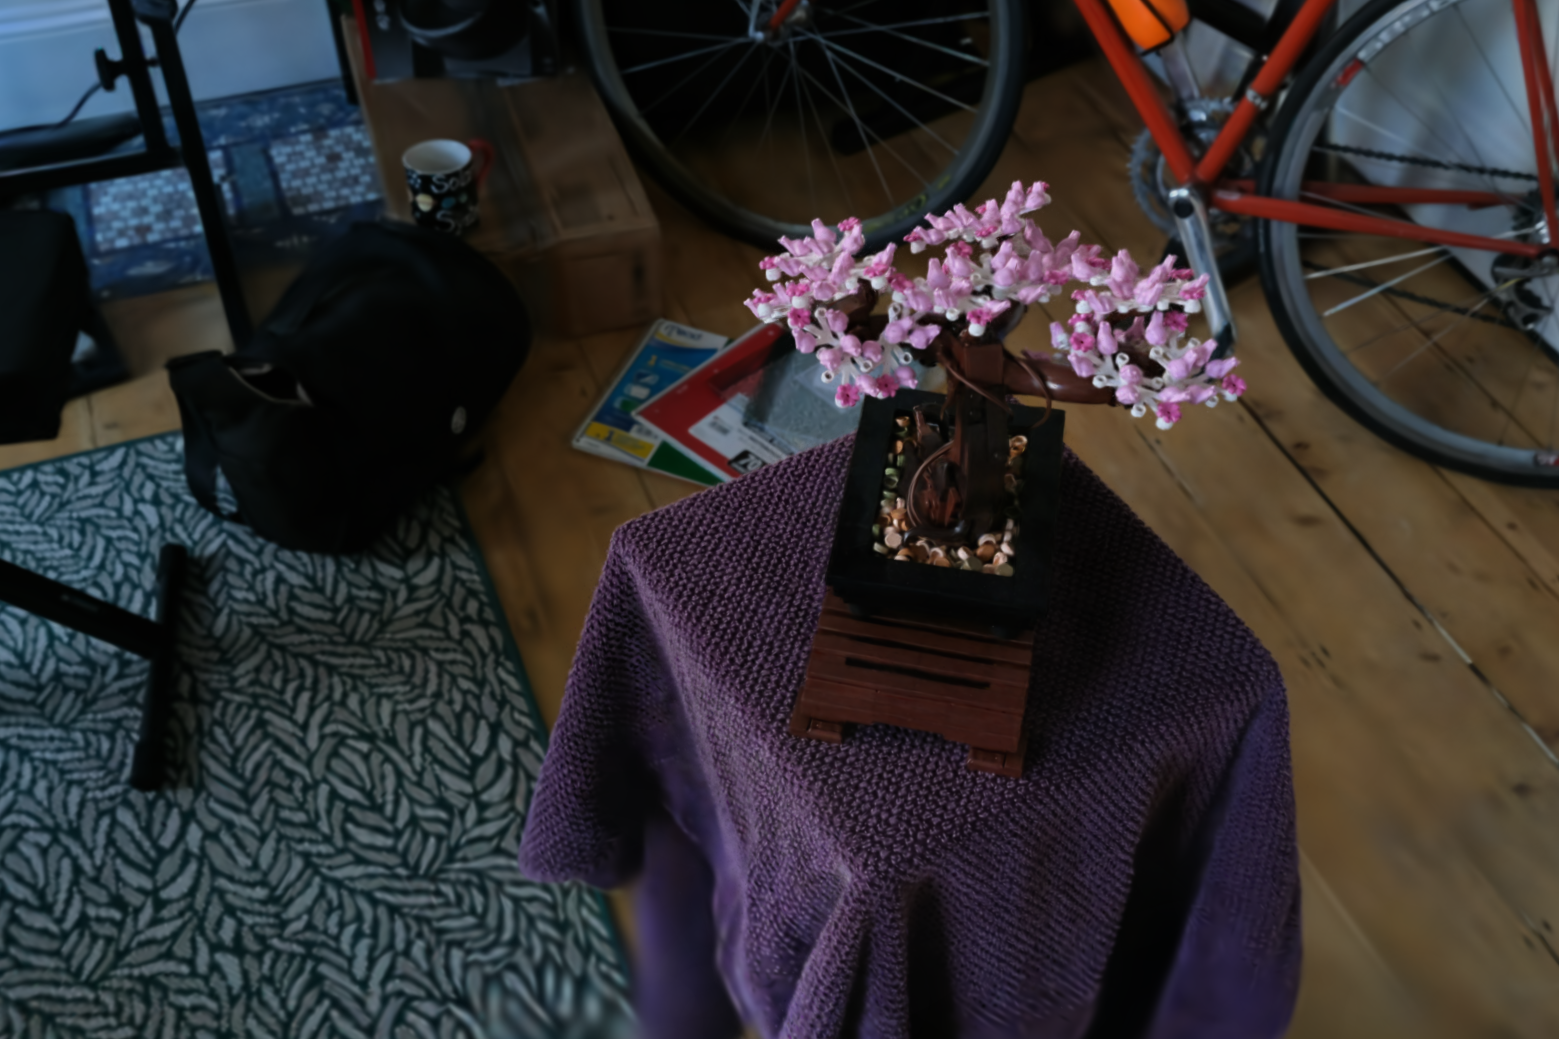

In [11]:
Image.fromarray((img.cpu().detach().numpy() * 255).astype(np.uint8))

In [12]:
color = torch.nn.Parameter(torch.zeros_like(color))
opacity_raw = torch.nn.Parameter(torch.zeros_like(opacity_raw))
scale_raw = torch.nn.Parameter(torch.randn_like(scale_raw) * 0.1 - 6.0)
rot_raw = torch.nn.Parameter(torch.rand_like(rot_raw) * 2.0 - 1.0)

optimizer = torch.optim.Adam([color] + [opacity_raw] + [scale_raw] + [rot_raw], lr=1e-1)

target_image = torch.from_numpy(
    np.array(Image.open(image_path).resize((W, H))) / 255.).to(device, dtype=torch.float32)

training_loss = []

for iteration in tqdm(range(100)):
    sigma = build_covariance(scale_raw, rot_raw)

    img = RasterizerFunction.apply(pos, color, opacity_raw, sigma, c2w, H, W, fx, fy, cx, cy)

    loss = torch.nn.functional.l1_loss(img, target_image)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    training_loss.append(loss.item())

100%|██████████| 100/100 [3:01:45<00:00, 109.05s/it] 


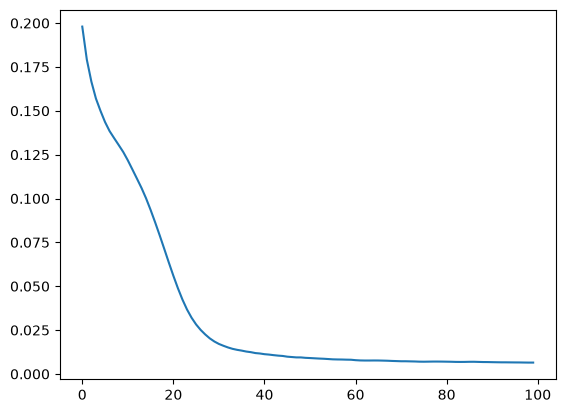

In [13]:
plt.plot(training_loss)

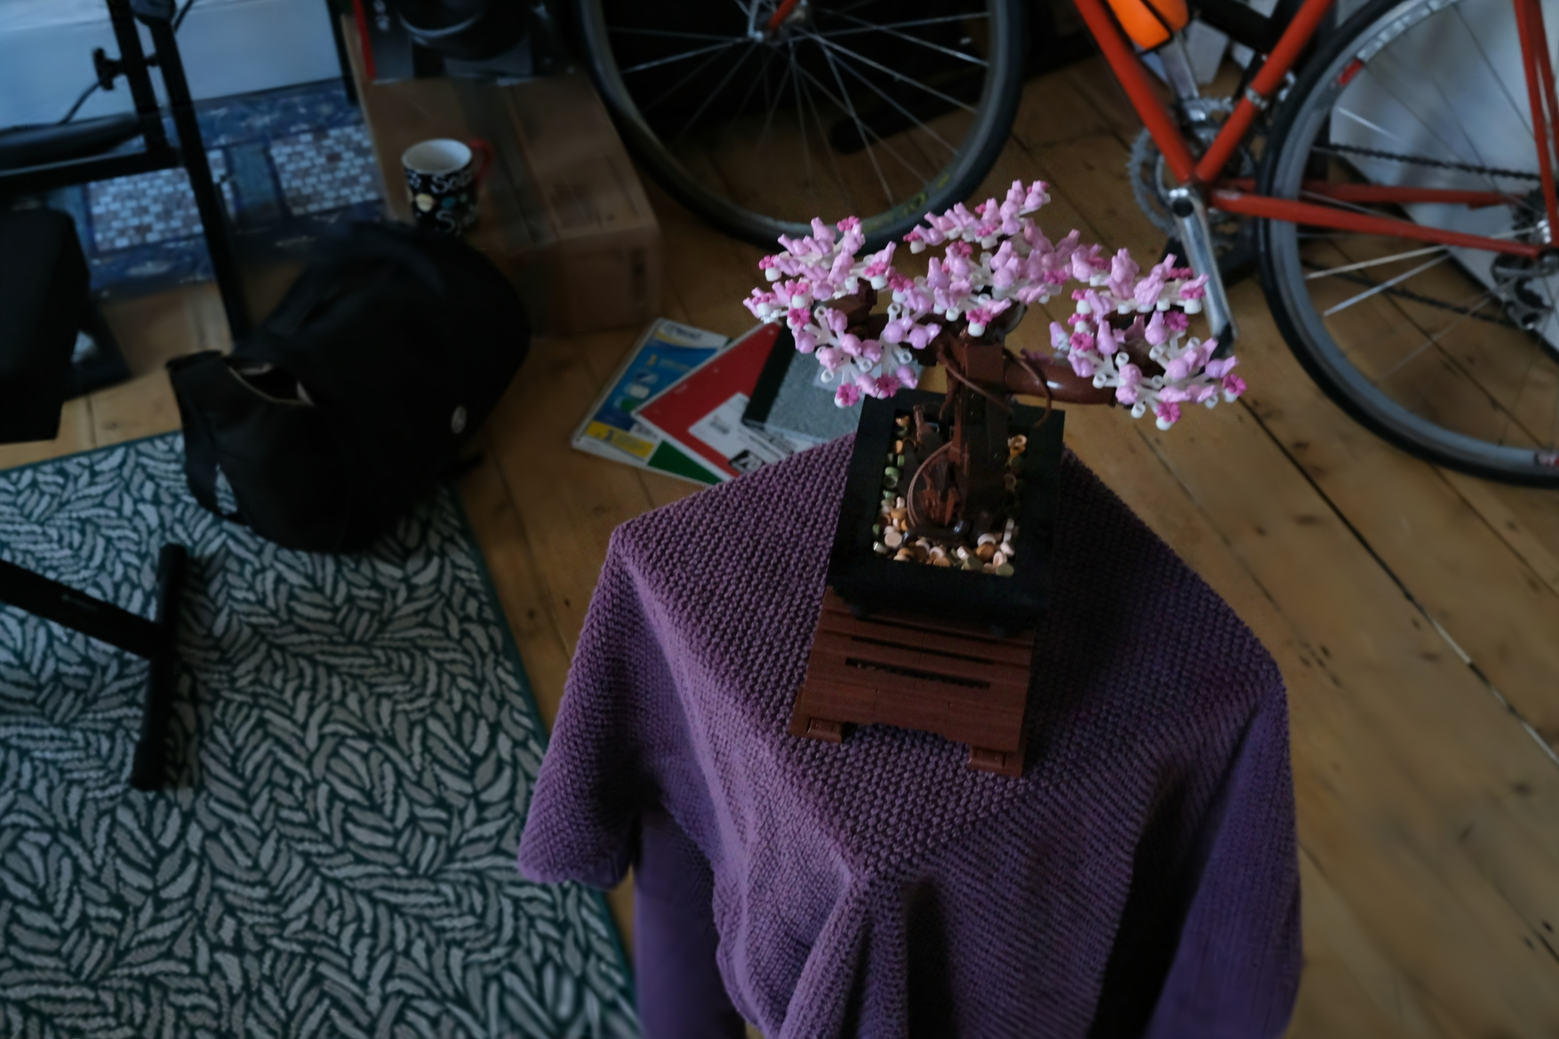

In [14]:
Image.fromarray((img.cpu().detach().numpy() * 255).astype(np.uint8))